<a href="https://colab.research.google.com/github/shivanshukashyap284-droid/-projectname---Employee-Salary-Prediction/blob/main/day_5_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Daily_Cal_Req.csv to Daily_Cal_Req.csv


In [2]:
import pandas as pd

In [4]:


df = pd.read_csv("Daily_Cal_Req.csv")
df.head()

,Age,Gender,Height_cm,Weight_kg,Activity_Level,Sleep_Hours,Water_Intake_L,Goal,Diet_Type,Daily_Calorie_Requirement
0,58.0,Male,151.0,80.0,Light,5.6,3.6,Gain,Veg,2306
1,46.0,Female,150.0,65.0,Active,6.2,1.5,Maintain,Veg,2064
2,53.0,Female,190.0,91.0,Very Active,5.5,1.2,Gain,Non-Veg,3476
3,60.0,Female,154.0,66.0,Very Active,8.1,1.6,Gain,Vegan,2207
4,35.0,Male,163.0,85.0,Light,7.8,2.4,Gain,Jain,2636


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        225 non-null    float64
 1   Gender                     225 non-null    object 
 2   Height_cm                  250 non-null    float64
 3   Weight_kg                  250 non-null    float64
 4   Activity_Level             250 non-null    object 
 5   Sleep_Hours                250 non-null    float64
 6   Water_Intake_L             250 non-null    float64
 7   Goal                       250 non-null    object 
 8   Diet_Type                  250 non-null    object 
 9   Daily_Calorie_Requirement  250 non-null    int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 19.7+ KB


In [6]:
df.shape

(250, 10)

In [7]:
df.isnull().sum()

,0
Age,25
Gender,25
Height_cm,0
Weight_kg,0
Activity_Level,0
Sleep_Hours,0
Water_Intake_L,0
Goal,0
Diet_Type,0
Daily_Calorie_Requirement,0


In [8]:
df.describe()

,Age,Height_cm,Weight_kg,Sleep_Hours,Water_Intake_L,Daily_Calorie_Requirement
count,225.000000,250.00000,250.000000,250.000000,250.000000,250.00000
mean,40.066667,170.50800,78.168000,7.158000,2.775200,2462.46000
std,12.006695,11.44438,18.307606,1.424272,0.965564,553.84209
min,18.000000,150.00000,45.000000,4.500000,1.000000,1167.00000
25%,30.000000,161.00000,64.000000,6.000000,2.000000,2088.50000
50%,40.000000,171.00000,81.000000,7.200000,2.700000,2404.00000
75%,51.000000,180.00000,91.000000,8.475000,3.600000,2823.50000
max,60.000000,190.00000,110.000000,9.500000,4.500000,4107.00000


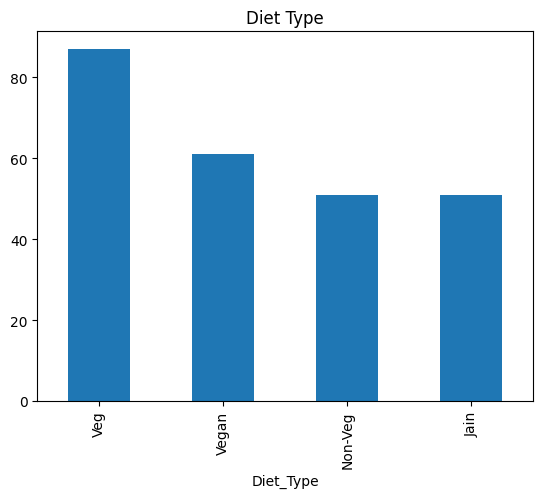

In [9]:
import matplotlib.pyplot as plt

df["Diet_Type"].value_counts().plot(kind="bar")
plt.title("Diet Type")
plt.show()

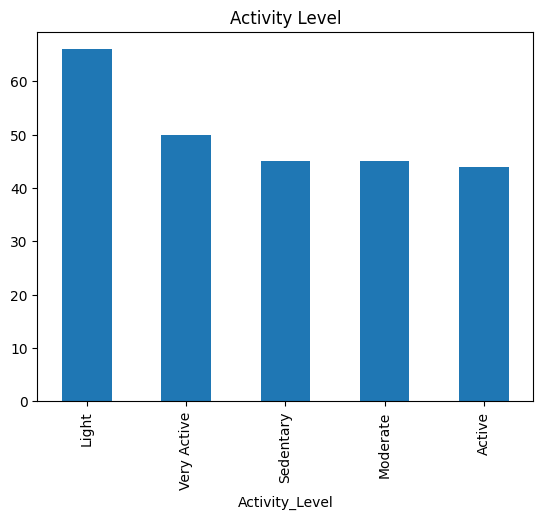

In [10]:
df["Activity_Level"].value_counts().plot(kind="bar")
plt.title("Activity Level")
plt.show()

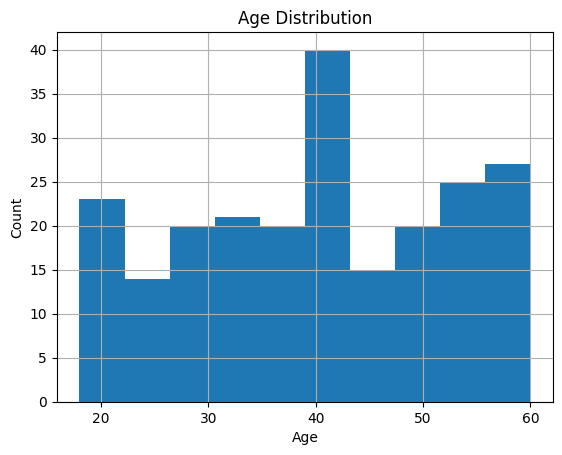

In [11]:
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

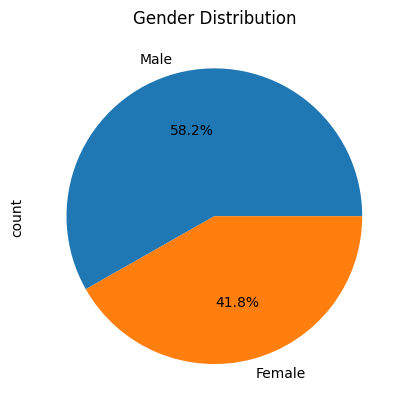

In [12]:
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

In [13]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Activity_Level',
       'Sleep_Hours', 'Water_Intake_L', 'Goal', 'Diet_Type',
       'Daily_Calorie_Requirement'],
      dtype='object')

Goal
Gain        2615.526786
Lose        2240.000000
Maintain    2436.463768
Name: Daily_Calorie_Requirement, dtype: float64


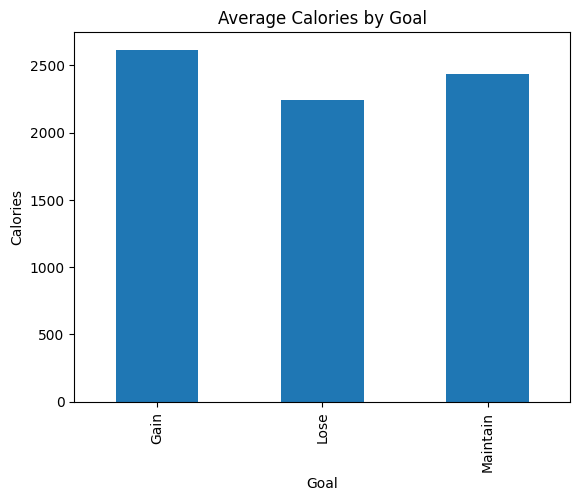

In [14]:
import matplotlib.pyplot as plt

goal_cal = df.groupby("Goal")["Daily_Calorie_Requirement"].mean()
print(goal_cal)

goal_cal.plot(kind="bar")
plt.title("Average Calories by Goal")
plt.ylabel("Calories")
plt.show()

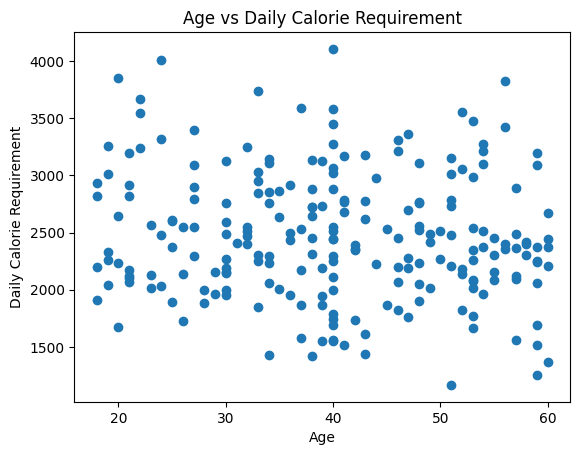

In [15]:
plt.scatter(df["Age"], df["Daily_Calorie_Requirement"])
plt.xlabel("Age")
plt.ylabel("Daily Calorie Requirement")
plt.title("Age vs Daily Calorie Requirement")
plt.show()

Activity_Level
Active         2.959091
Light          2.701515
Moderate       2.660000
Sedentary      2.957778
Very Active    2.650000
Name: Water_Intake_L, dtype: float64


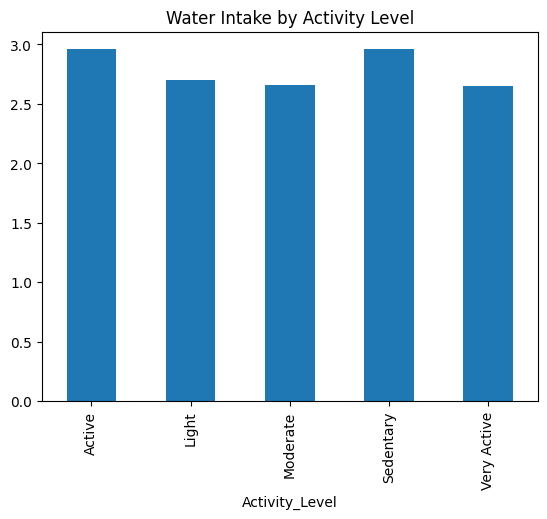

In [16]:
water = df.groupby("Activity_Level")["Water_Intake_L"].mean()
print(water)

water.plot(kind="bar")
plt.title("Water Intake by Activity Level")
plt.show()

In [17]:
!pip install plotly

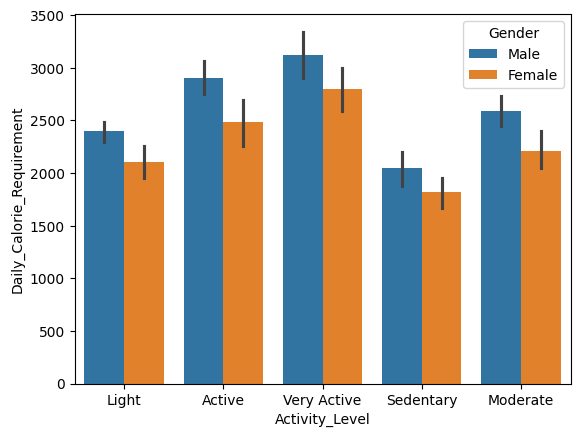

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="Activity_Level",
    y="Daily_Calorie_Requirement",
    hue="Gender"
)

plt.show()

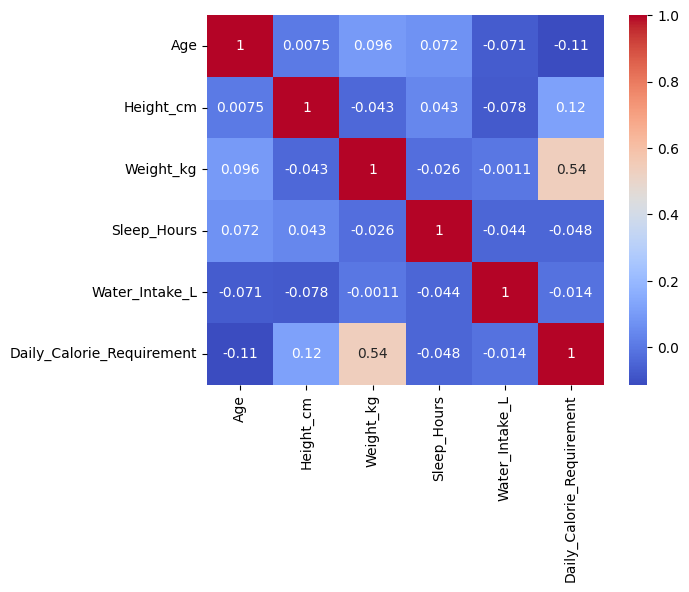

In [19]:
import seaborn as sns

sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [20]:
import plotly.express as px

fig = px.treemap(
    df,
    path=["Goal","Activity_Level","Diet_Type"]
)

fig.show()

In [22]:
fig = px.sunburst(
    df,
    path=["Goal","Activity_Level","Diet_Type"]
)

fig.show()

In [23]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [24]:
X = df.drop("Daily_Calorie_Requirement", axis=1)
y = df["Daily_Calorie_Requirement"]

In [25]:
X = pd.get_dummies(X, drop_first=True)

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 51310.36067325495


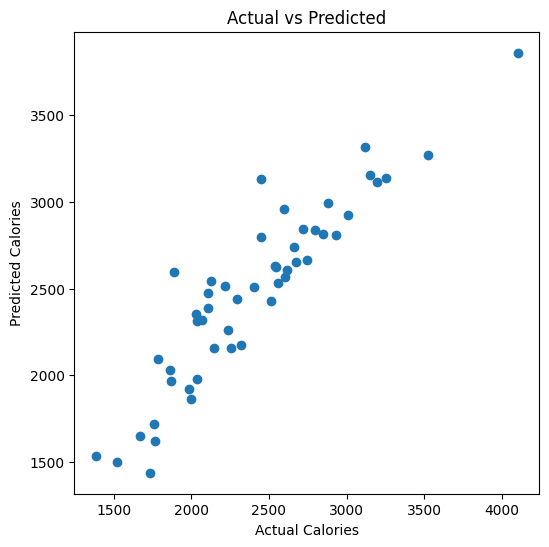

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted")
plt.show()